In [14]:
from ultralytics import YOLO
import yaml
import os
import torch
import random
import shutil

# ------------------------------
# CUDA / GPU Info
# ------------------------------
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("Device count:", torch.cuda.device_count())
    print("Device name:", torch.cuda.get_device_name(0))
else:
    print("⚠️ CUDA not available — training will run on CPU.")

# ------------------------------
# Define base paths and classes
# ------------------------------
base_path1 = "Road_Signs_Detection_Dataset"
train_img_dir = os.path.join(base_path1, "train/images")
train_lbl_dir = os.path.join(base_path1, "train/labels")

val_img_dir = os.path.join(base_path1, "val/images")
val_lbl_dir = os.path.join(base_path1, "val/labels")

# Create val folders if missing
os.makedirs(val_img_dir, exist_ok=True)
os.makedirs(val_lbl_dir, exist_ok=True)

CLASS_NAMES = [
    'stop', 'yield', 'speed_limit', 'no_entry', 'turn_left', 'turn_right',
    'pedestrian', 'school_zone', 'railroad_crossing', 'construction',
    'traffic_light', 'roundabout', 'parking', 'bicycle'
]

# ------------------------------
# Split train → train + val
# ------------------------------
val_ratio = 0.2  # 20% of training data for validation

# List all image files
images = [f for f in os.listdir(train_img_dir) if f.lower().endswith((".jpg", ".png", ".jpeg"))]
random.shuffle(images)
num_val = int(len(images) * val_ratio)
val_images = images[:num_val]

print(f"Total images: {len(images)}")
print(f"Creating validation split: {len(val_images)} images (≈{val_ratio*100:.0f}% of training data)")

# Copy files (use shutil.move if you prefer to move)
for img in val_images:
    img_src = os.path.join(train_img_dir, img)
    lbl_src = os.path.join(train_lbl_dir, os.path.splitext(img)[0] + ".txt")

    img_dst = os.path.join(val_img_dir, img)
    lbl_dst = os.path.join(val_lbl_dir, os.path.splitext(img)[0] + ".txt")

    shutil.copy(img_src, img_dst)
    if os.path.exists(lbl_src):
        shutil.copy(lbl_src, lbl_dst)

# ------------------------------
# Create dataset.yaml
# ------------------------------
dataset_yaml = {
    'train': os.path.join(base_path1, 'train/images'),
    'val': os.path.join(base_path1, 'val/images'),
    'nc': len(CLASS_NAMES),
    'names': CLASS_NAMES
}

yaml_path = os.path.join(os.getcwd(), 'dataset.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_yaml, f)

print("\n✅ dataset.yaml created successfully:")
with open(yaml_path, 'r') as f:
    print(f.read())

# ------------------------------
# Train YOLO model
# ------------------------------
print("\n🚀 Starting YOLO training...")
model = YOLO('yolov8n.pt')  # You can change to yolov8s.pt, yolov8m.pt, etc.

results = model.train(
    data=yaml_path,
    epochs=5,        # quick test
    imgsz=256,
    batch=8,
    lr0=1e-2,
    patience=3,
    device=0 if torch.cuda.is_available() else 'cpu',
    name='road_signs_fast_test'
)

# ------------------------------
# Validate model and print metrics
# ------------------------------
print("\n📊 Evaluating model on validation set...")
metrics = model.val()
print(metrics)


CUDA available: True
CUDA version: 12.1
Device count: 1
Device name: NVIDIA GeForce RTX 4050 Laptop GPU
Total images: 3464
Creating validation split: 692 images (≈20% of training data)

✅ dataset.yaml created successfully:
names:
- stop
- yield
- speed_limit
- no_entry
- turn_left
- turn_right
- pedestrian
- school_zone
- railroad_crossing
- construction
- traffic_light
- roundabout
- parking
- bicycle
nc: 14
train: Road_Signs_Detection_Dataset\train/images
val: Road_Signs_Detection_Dataset\val/images


🚀 Starting YOLO training...
Ultralytics 8.3.228  Python-3.12.7 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\songy\McGill\ComputerVisionMiscellaneous\dataset.yaml, degrees=0.0, determin


📊 Evaluation Results:
stop                 F1 = 0.397
yield                F1 = 0.477
speed_limit          F1 = 0.455
no_entry             F1 = 0.148
turn_left            F1 = 0.541
turn_right           F1 = 0.552
pedestrian           F1 = 0.967
school_zone          F1 = 0.607
railroad_crossing    F1 = 0.608
construction         F1 = 0.845
traffic_light        F1 = 0.427
roundabout           F1 = 0.403
parking              F1 = 0.479
bicycle              F1 = 0.498

Average F1-score: 0.529
mAP@50: 0.503
mAP@50–95: 0.426


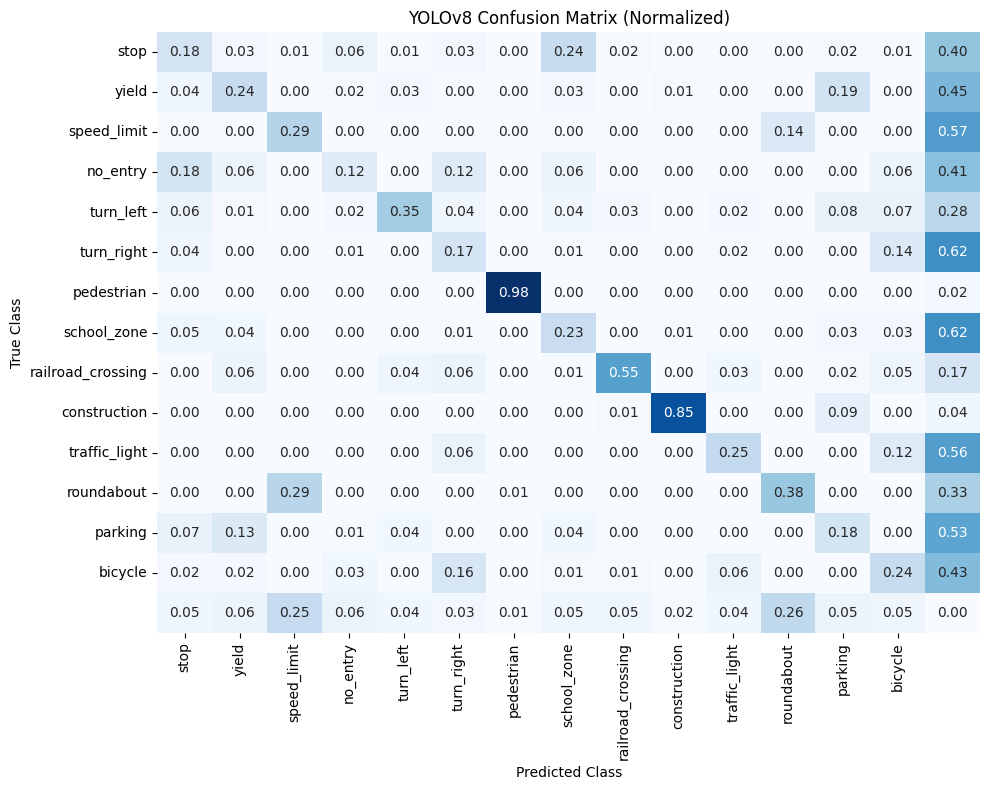

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Extract metrics
map50 = results.box.map50        # mAP at IoU = 0.50
map5095 = results.box.map        # mAP averaged from 0.50–0.95

# Per-class precision, recall, and F1
prec = np.array(results.box.p)
rec = np.array(results.box.r)
f1_scores = np.array(results.box.f1)
avg_f1 = np.mean(f1_scores)

print("\n📊 Evaluation Results:")
for name, f1 in zip(results.names.values(), f1_scores):
    print(f"{name:20s} F1 = {f1:.3f}")

print(f"\nAverage F1-score: {avg_f1:.3f}")
print(f"mAP@50: {map50:.3f}")
print(f"mAP@50–95: {map5095:.3f}")

cm = results.confusion_matrix.matrix  # shape: [num_classes, num_classes]
labels = list(results.names.values())

# Normalize for readability (each row sums to 1)
cm_norm = cm / (cm.sum(axis=1, keepdims=True) + 1e-6)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    xticklabels=labels,
    yticklabels=labels,
    cmap="Blues",
    cbar=False
)
%matplotlib inline
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("YOLOv8 Confusion Matrix (Normalized)")
plt.tight_layout()
plt.show()